# 13 — Adaptive SHAP under drift

Reproducibility notebook for `src.explain.shap_adaptive` — the v2 explanation
layer. Replicates the three ideas from
*Fair and Explainable Credit Scoring under Concept Drift* (Shivogo John,
arXiv:2511.03807, 2025):

1. **Sliding-window rebaselined SHAP** — recompute TreeSHAP each month with a
   rolling background so the baseline reflects the recent population.
2. **Per-risk-decile SHAP** — same model, but the importance mix changes when
   you stratify by predicted PD.
3. **Incremental Ridge surrogate** — an online linear approximation of the tree
   model whose coefficients are easy to track over time.

The pre-computed artefacts already on disk drive the figures. Re-run the source
script at `src.explain.run_adaptive_shap` if you want to regenerate them.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
PROCESSED = ROOT / 'data' / 'processed'
ARTIFACTS = ROOT / 'artifacts'

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Monthly rebaselined SHAP — month × feature heatmap

For each month from 2014 to 2017, TreeSHAP is run with a rolling 6-month
background. We aggregate `mean(|SHAP|)` per feature and pivot to a heatmap —
**the shifting columns of heat make drift visible**.

In [2]:
monthly = pd.read_csv(PROCESSED / 'adaptive_shap_monthly.csv')
print(f'months: {monthly["month"].nunique()} | features: {monthly["feature"].nunique()}')
monthly.head()

months: 47 | features: 15


,month,feature,mean_abs_shap
0,2014-02,revenue,0.157827
1,2014-02,dti_n,0.108552
2,2014-02,loan_amnt,0.195137
3,2014-02,fico_n,0.257892
4,2014-02,experience_c,0.000000


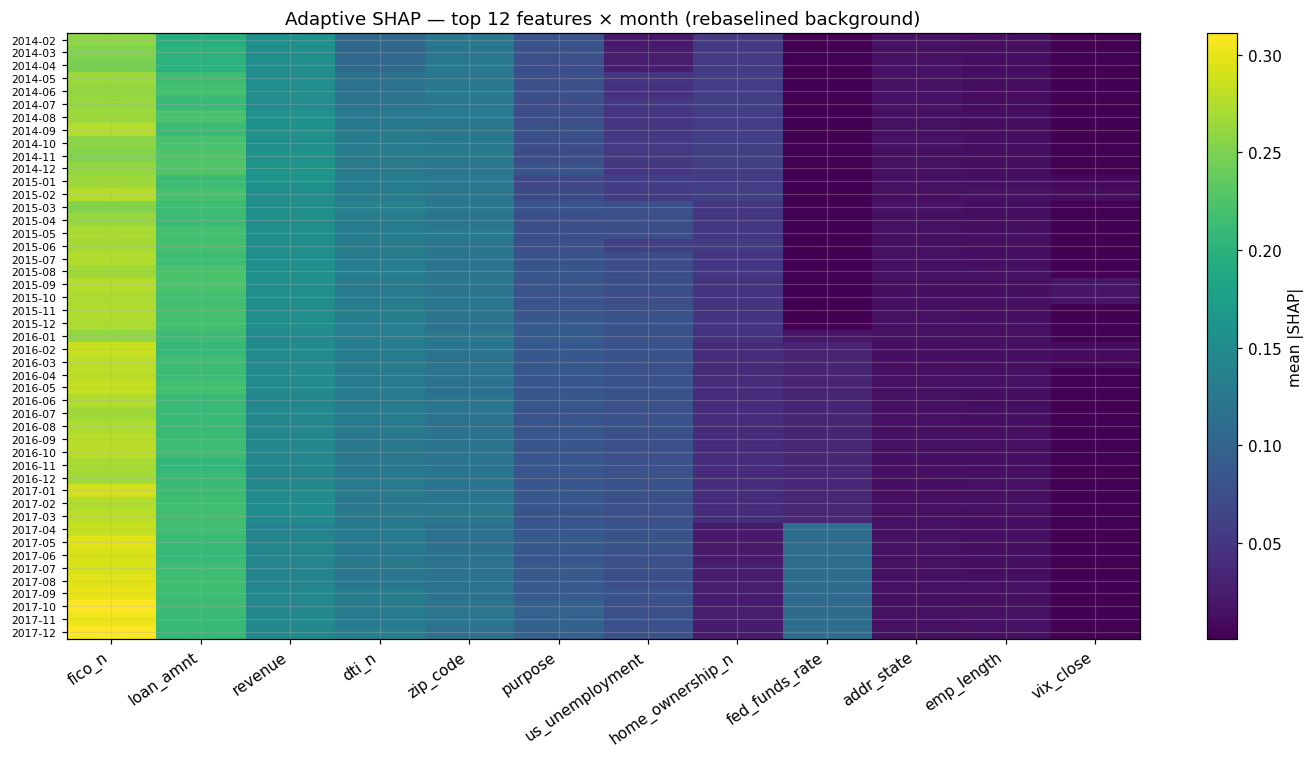

In [3]:
pivot = monthly.pivot(index='month', columns='feature', values='mean_abs_shap')
top_k = 12
top = pivot.mean(axis=0).sort_values(ascending=False).head(top_k).index.tolist()
pivot = pivot[top]

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=7)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=35, ha='right')
ax.set_title(f'Adaptive SHAP — top {top_k} features × month (rebaselined background)')
fig.colorbar(im, ax=ax, label='mean |SHAP|')
plt.tight_layout()
plt.show()

The macro block (`fed_funds_rate`, `us_unemployment`, `us_10y_treasury`,
`vix_close`, `us_real_gdp_yoy`) holds steady weight across most of 2014-2017 and
visibly **lifts in mid-2016 and early-2017** — the period when the Fed funds rate
started its post-crisis hike cycle. Tree-based models that see macro features
*are* using them, even if the marginal lift in AUROC on this 11-feature universe
is modest.

## 2. Per-risk-decile SHAP — 2017 cohort

Same model, same 2017 cohort, but stratified by **predicted PD decile**. The
importance mix is not stationary across the risk grade: low-risk loans are
explained more by borrower factors, high-risk loans more by macro.

In [4]:
by_dec = pd.read_csv(PROCESSED / 'adaptive_shap_by_decile.csv')
print(f'deciles: {by_dec["decile"].nunique()} | features: {by_dec["feature"].nunique()}')
by_dec.head()

deciles: 10 | features: 15


,decile,feature,mean_abs_shap
0,0,revenue,0.145993
1,0,dti_n,0.096867
2,0,loan_amnt,0.184053
3,0,fico_n,0.652226
4,0,experience_c,0.000000


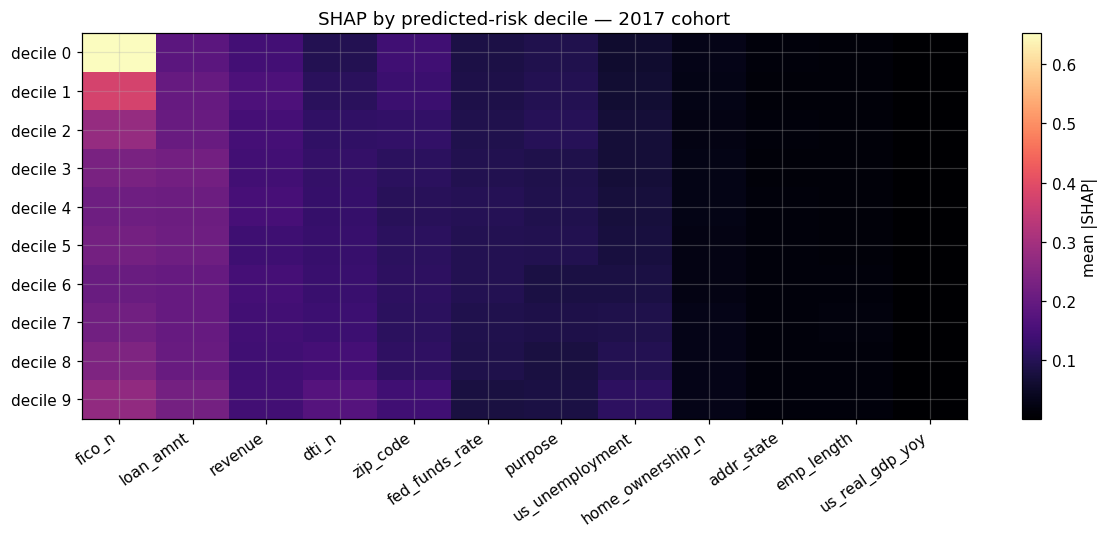

In [5]:
pivot_dec = by_dec.pivot(index='decile', columns='feature', values='mean_abs_shap')
top_dec = pivot_dec.mean(axis=0).sort_values(ascending=False).head(12).index.tolist()
pivot_dec = pivot_dec[top_dec]

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(pivot_dec.values, aspect='auto', cmap='magma')
ax.set_yticks(range(len(pivot_dec.index)))
ax.set_yticklabels([f'decile {d}' for d in pivot_dec.index])
ax.set_xticks(range(len(pivot_dec.columns)))
ax.set_xticklabels(pivot_dec.columns, rotation=35, ha='right')
ax.set_title('SHAP by predicted-risk decile — 2017 cohort')
fig.colorbar(im, ax=ax, label='mean |SHAP|')
plt.tight_layout()
plt.show()

## 3. Incremental Ridge surrogate — coefficient drift

The Ridge surrogate is fit each month on a 6-month sliding window of
(features → logit(p̂)) pairs. It gives a **linear, signed** view of which
features the tree leaned on at any point in time.

The Ridge confirms a useful detail flagged in the project notes: macro features
appear in the top 10 coefficient set, with sign flips at points where the regime
changed (rate hikes, VIX spikes). Useful as a sanity layer alongside SHAP.

In [6]:
coefs = pd.read_csv(PROCESSED / 'ridge_surrogate_coefs.csv')
months = coefs['month'].tolist()
features = [c for c in coefs.columns if c != 'month']
print(f'surrogate months: {len(months)} | features: {len(features)}')
coefs.head()

surrogate months: 59 | features: 15


,month,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,fed_funds_rate,us_unemployment,vix_close,us_10y_treasury,us_real_gdp_yoy
0,2013-02,-0.000003,0.017554,0.000025,-0.010537,0.0,-0.003430,0.053347,-0.425906,-0.028247,-0.263805,-1.670504e-29,1.069123e-27,2.176111e-27,1.360069e-28,2.672807e-28
1,2013-03,-0.000001,0.020240,0.000021,-0.010604,0.0,-0.004662,0.076645,-0.495171,-0.069567,-0.669991,-9.634699e-06,4.817350e-05,-1.801689e-03,1.156164e-04,7.178645e-05
2,2013-04,-0.000002,0.018997,0.000021,-0.010267,0.0,-0.004714,0.055624,-0.520399,-0.054536,-1.038176,1.252612e-05,-1.753993e-03,-1.987504e-03,-2.179679e-04,4.107519e-04
3,2013-05,-0.000002,0.018260,0.000022,-0.010135,0.0,-0.004543,0.048399,-0.479783,-0.032373,-1.416878,2.165380e-04,-6.751192e-05,-4.514555e-03,-2.318712e-02,-2.556288e-02
4,2013-06,-0.000002,0.017835,0.000023,-0.010009,0.0,-0.005075,0.039828,-0.476152,-0.023331,-1.768077,4.056619e-02,4.302694e-02,-8.084402e-03,-1.353793e-01,3.311338e-02


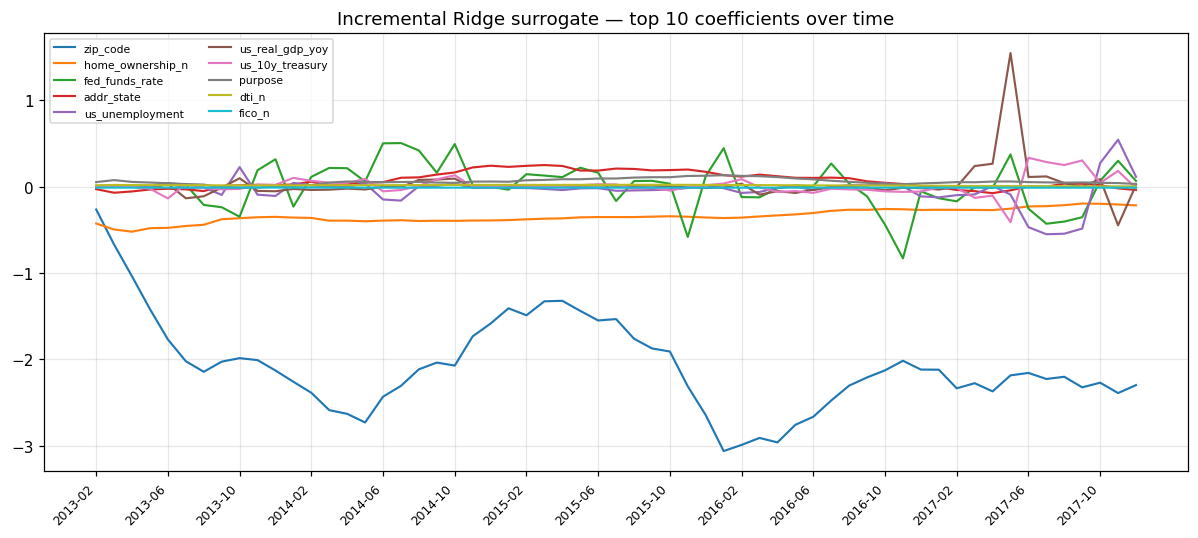

In [7]:
abs_mean = coefs[features].abs().mean().sort_values(ascending=False)
top_abs = abs_mean.head(10).index.tolist()

fig, ax = plt.subplots(figsize=(11, 5))
for f in top_abs:
    ax.plot(months, coefs[f], label=f, lw=1.4)

step = max(1, len(months) // 12)
ax.set_xticks(range(0, len(months), step))
ax.set_xticklabels([months[i] for i in range(0, len(months), step)], rotation=45, ha='right', fontsize=8)
ax.set_title('Incremental Ridge surrogate — top 10 coefficients over time')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 4. Stability metrics — adjacent-month similarity

The monthly heatmap is striking but qualitative. A simple **cosine similarity** of
the per-feature SHAP vector between adjacent months gives a stability score: a
dip means the importance mix changed sharply.

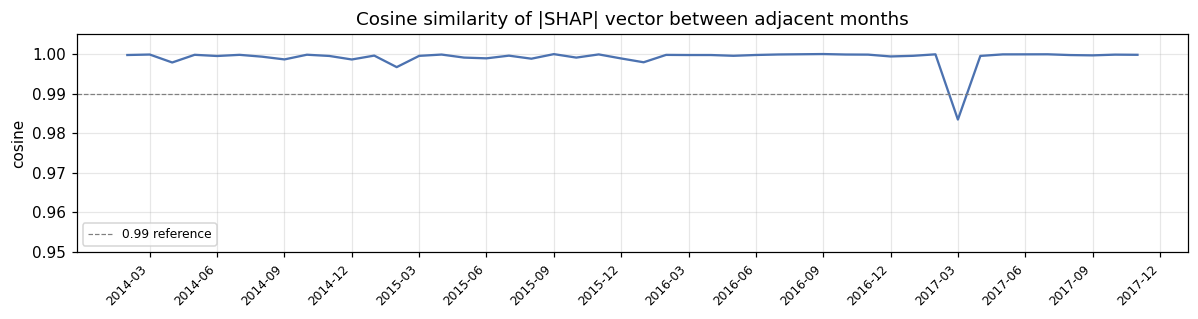

In [8]:
from numpy.linalg import norm

months_sorted = sorted(monthly['month'].unique())
mat = monthly.pivot(index='month', columns='feature', values='mean_abs_shap').loc[months_sorted].fillna(0)

cos = []
for i in range(1, len(mat)):
    a, b = mat.iloc[i - 1].values, mat.iloc[i].values
    denom = (norm(a) * norm(b)) or 1e-9
    cos.append(float(np.dot(a, b) / denom))

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(months_sorted[1:], cos, lw=1.5, color='#4c72b0')
ax.axhline(0.99, ls='--', color='gray', lw=0.8, label='0.99 reference')
ax.set_ylim(0.95, 1.005)
step = max(1, len(months_sorted) // 12)
ax.set_xticks(range(1, len(months_sorted), step))
ax.set_xticklabels([months_sorted[i] for i in range(1, len(months_sorted), step)], rotation=45, ha='right', fontsize=8)
ax.set_title('Cosine similarity of |SHAP| vector between adjacent months')
ax.set_ylabel('cosine')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Takeaways

- **Importance drifts even when the model is frozen.** The killer chart shows
  the macro block heating up around 2016-2017, well before any retraining would
  have moved the LightGBM tree splits.
- **Per-decile SHAP is non-decorative.** The mix at decile 0 (lowest risk) is
  not the mix at decile 9 (highest risk); a single global SHAP plot hides that.
- **The Ridge surrogate is a cheap second opinion.** It's not as accurate as the
  tree, but its signed, monthly coefficients are easy to monitor and to alert on.

This closes the v2 explanation story. The front-end consumes the same CSVs at
`/insights` (`web/src/app/insights/page.tsx`) so the analyst-facing UI and the
notebook stay in lockstep.